In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
hits_path = Path("ptcl_literature_hits.tsv")
hits = pd.read_csv(hits_path, sep="\t")

In [3]:
#a list of genes curated from scientific literature on PTCL, NOS
PTCL_LITERATURE_GENES = [
    #cell cycle/ tumour suppressors
    "TP53", "CDKN2A", "RB1", "ATM", "TNFRSF14",
    #epigenetic regulators
    "TET2", "DNMT3A", "IDH2", "KMT2D", "SETD2", "SETDB1", "EZH2",
    #TCR/signalling
    "RHOA", "PLCG1", "FYN", "VAV1", "CD28", "CTLA4", "PIK3CA", "AKT1", "AKT2",
    "STAT3", "STAT5B", "JAK1", "JAK3", "IRF4", "PRKCB",
    #TFH/TF
    "GATA3", "TBX21", "BCL11B", "ZEB1", "MYC", "BCL2",
    #apoptosis
    "CARD11", "BCL10", "FAS", "TNFRSF1A",
    #others
    "MTOR", "PRDM2", "PRDM16", "LATS2", "RPL22", "TCL1A", "NOTCH1", "NOTCH2"
]

In [4]:
#mapping events to numbers for a categorical heatmap
event_rank = {
    "": 0,
    "NONE": 0,
    "HETD": 1,
    "GAIN": 2,
    "AMP": 3,
    "HLAMP": 4,
    "HLAMP2": 5,
    "HLAMP3": 6
}

In [5]:
hits["event"] = hits["event"].astype(str).str.upper().str.strip()

In [6]:
#simple function to return rank
def max_event_rank(group):
    return max(event_rank.get(ev, 0) for ev in group)

In [11]:
patients = ["RDV", "MMS"]
matrix = pd.DataFrame(0, index=PTCL_LITERATURE_GENES, columns=patients)

In [13]:
for patient in patients:
    sub = hits[hits["patient"] == patient]
    if sub.empty:
        continue
    ranks = (
        sub.groupby("gene_name")["event"]
           .apply(max_event_rank)
           .to_dict()
    )
    for g in PTCL_LITERATURE_GENES:
        matrix.loc[g, patient] = int(ranks.get(g, 0))


In [14]:
matrix_nonzero = matrix[(matrix.sum(axis=1) > 0)]
matrix_nonzero.to_csv("heatmap_matrix.csv", index=True)

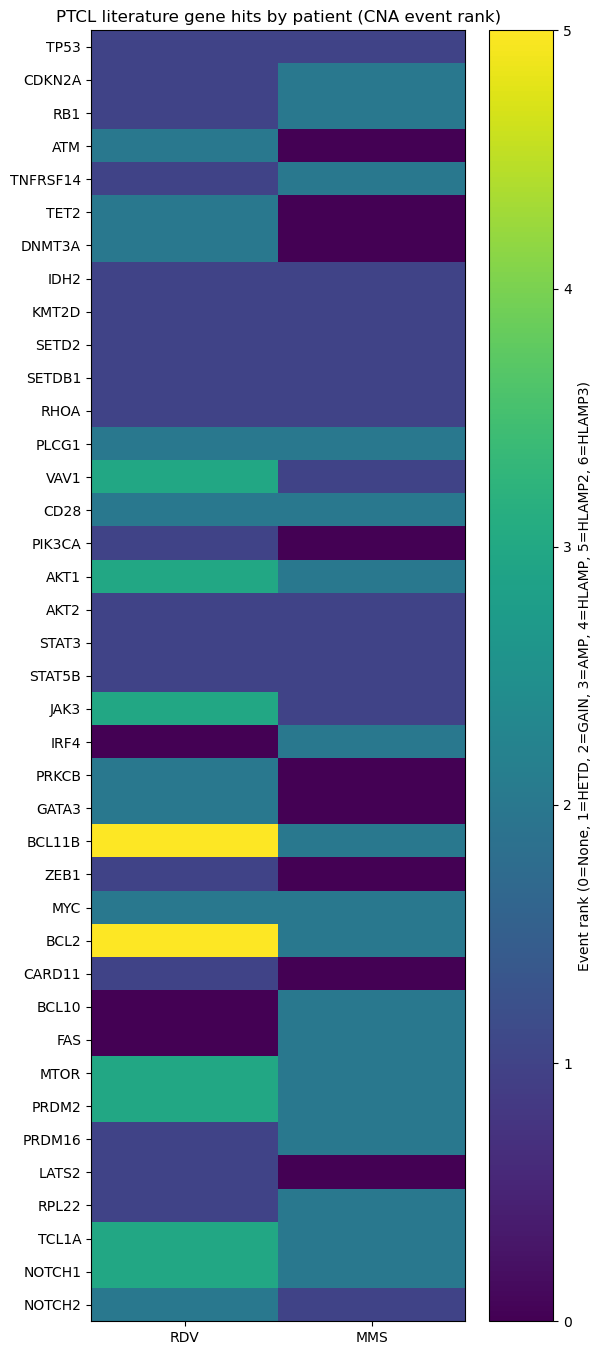

In [18]:
#plotting
plt.figure(figsize=(6, max(8, 0.35 * matrix_nonzero.shape[0])))
plt.imshow(matrix_nonzero.values, aspect="auto")
plt.colorbar(label="Event rank (0=None, 1=HETD, 2=GAIN, 3=AMP, 4=HLAMP, 5=HLAMP2, 6=HLAMP3)")
plt.xticks(ticks=np.arange(matrix_nonzero.shape[1]), labels=matrix_nonzero.columns, rotation=0)
plt.yticks(ticks=np.arange(matrix_nonzero.shape[0]), labels=matrix_nonzero.index)
plt.title("PTCL literature gene hits by patient (CNA event rank)")
plt.tight_layout()
plt.savefig("heatmap_CNA")